# 6. Thermo-hygrometric modelling — corrected

This notebook contains only the analyses used in the manuscript: corrected thermo-hygrometric preprocessing, the sensible/latent driving-force figure, nested LOSO comparison of M0–M2, and Figure 7. Legacy RH correlations, the outcome-percentile filter and the former lagged-OLS analysis have been removed.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Project root containing the data directory was not found.")


ROOT = find_project_root()
INPUT_PATH = ROOT / "data" / "processed" / "analysis" / "analysis_wide_thermodynamics.csv"
OUTPUT_DIR = ROOT / "reports" / "9_humidity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TIME_STEP_SECONDS = 10
MAX_INTERPOLATED_SAMPLES = 2
SMOOTHING_WINDOW_SAMPLES = 5

CONDITION_ORDER = ["no_wind", "wind_low", "wind_high"]
PHASE_BOUNDS_SECONDS = {
    "standing_1": (0, 600),
    "walk_low_1": (600, 1200),
    "walk_mod_1": (1200, 1800),
    "walk_low_2": (1800, 2400),
    "walk_mod_2": (2400, 3000),
    "standing_2": (3000, 3600),
}

print("Project root:", ROOT)


Project root: /home/eleonorab/repository/convective_cooling


## 1. Signal preprocessing and local driving forces


In [2]:
# ============================================================
# THERMO-HYGROMETRIC PREPROCESSING
# ============================================================

analysis_wide_path = (
    ROOT / "data" / "processed" / "analysis" / "analysis_dataset_wide.csv"
)
df_wide = pd.read_csv(analysis_wide_path)

required_columns = [
    "subject_id", "condition", "phase", "elapsed_seconds",
    "t_dorsal", "rh_dorsal", "t_microclimateback", "rh_microclimateback",
]
missing_columns = [column for column in required_columns if column not in df_wide]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

df_wide["subject_id"] = df_wide["subject_id"].astype(str).str.strip()
df_wide["condition"] = df_wide["condition"].astype(str).str.strip().str.lower()

measurement_columns = [
    "t_dorsal", "rh_dorsal", "t_microclimateback", "rh_microclimateback",
]
for column in ["elapsed_seconds", *measurement_columns]:
    df_wide[column] = pd.to_numeric(df_wide[column], errors="coerce")

df_wide = df_wide.dropna(
    subset=["subject_id", "condition", "phase", "elapsed_seconds"]
).copy()
df_wide = df_wide.loc[df_wide["elapsed_seconds"].between(0, 3599)].copy()
df_wide["elapsed_seconds_bin"] = (
    np.round(df_wide["elapsed_seconds"] / TIME_STEP_SECONDS) * TIME_STEP_SECONDS
).astype(int)

df_regular = (
    df_wide.groupby(
        ["subject_id", "condition", "phase", "elapsed_seconds_bin"],
        observed=True,
        as_index=False,
    )[measurement_columns]
    .mean()
)


def complete_phase_grid(group: pd.DataFrame) -> pd.DataFrame:
    subject = group["subject_id"].iloc[0]
    condition = group["condition"].iloc[0]
    phase = group["phase"].iloc[0]
    start, end = PHASE_BOUNDS_SECONDS[phase]
    expected = np.arange(start, end, TIME_STEP_SECONDS, dtype=int)
    output = group.set_index("elapsed_seconds_bin").reindex(expected)
    output.index.name = "elapsed_seconds_bin"
    output["subject_id"] = subject
    output["condition"] = condition
    output["phase"] = phase
    return output.reset_index()


df_regular = pd.concat(
    [
        complete_phase_grid(group)
        for _, group in df_regular.groupby(
            ["subject_id", "condition", "phase"], observed=True, sort=False
        )
    ],
    ignore_index=True,
)

missing_before = df_regular[measurement_columns].isna().sum()


def interpolate_short_internal_gaps(
    series: pd.Series,
    max_samples: int = MAX_INTERPOLATED_SAMPLES,
) -> pd.Series:
    """Fill only complete internal gaps of at most two 10-s observations."""
    series = series.copy()
    missing = series.isna()
    if not missing.any():
        return series
    run_id = missing.ne(missing.shift(fill_value=False)).cumsum()
    run_length = missing.groupby(run_id).transform("sum")
    candidate = series.interpolate(method="index", limit_area="inside")
    fill_mask = missing & run_length.le(max_samples)
    series.loc[fill_mask] = candidate.loc[fill_mask]
    return series


def interpolate_phase(group: pd.DataFrame) -> pd.DataFrame:
    group = group.sort_values("elapsed_seconds_bin").copy()
    group = group.set_index("elapsed_seconds_bin")
    for column in measurement_columns:
        group[column] = interpolate_short_internal_gaps(group[column])
    return group.reset_index()


df_regular = pd.concat(
    [
        interpolate_phase(group)
        for _, group in df_regular.groupby(
            ["subject_id", "condition", "phase"], observed=True, sort=False
        )
    ],
    ignore_index=True,
)

missing_after = df_regular[measurement_columns].isna().sum()
interpolation_summary = pd.DataFrame({
    "variable": measurement_columns,
    "missing_before": [missing_before[column] for column in measurement_columns],
    "interpolated": [
        missing_before[column] - missing_after[column]
        for column in measurement_columns
    ],
    "missing_after": [missing_after[column] for column in measurement_columns],
})


def calculate_vapor_pressure(temperature, relative_humidity):
    saturation_pressure = 0.61078 * np.exp(
        (17.27 * temperature) / (temperature + 237.3)
    )
    return saturation_pressure * relative_humidity / 100.0


df_regular["p_v_dorsal"] = calculate_vapor_pressure(
    df_regular["t_dorsal"], df_regular["rh_dorsal"]
)
df_regular["p_v_mc_back"] = calculate_vapor_pressure(
    df_regular["t_microclimateback"], df_regular["rh_microclimateback"]
)
df_regular["delta_T_loc"] = (
    df_regular["t_dorsal"] - df_regular["t_microclimateback"]
)
df_regular["delta_pv_loc"] = (
    df_regular["p_v_dorsal"] - df_regular["p_v_mc_back"]
)


def calculate_temperature_derivative(group: pd.DataFrame) -> pd.DataFrame:
    group = group.sort_values("elapsed_seconds_bin").copy()
    group["t_dorsal_smooth"] = group["t_dorsal"].rolling(
        window=SMOOTHING_WINDOW_SAMPLES,
        center=True,
        min_periods=3,
    ).mean()

    time_minutes = group["elapsed_seconds_bin"].to_numpy(float) / 60.0
    temperature = group["t_dorsal_smooth"].to_numpy(float)
    derivative = np.full(len(group), np.nan)
    valid = np.isfinite(time_minutes) & np.isfinite(temperature)
    run_id = pd.Series(valid).ne(pd.Series(valid).shift(fill_value=False)).cumsum()

    for current_run in np.unique(run_id[valid]):
        indices = np.where(valid & (run_id.to_numpy() == current_run))[0]
        if len(indices) >= 3:
            derivative[indices] = np.gradient(
                temperature[indices], time_minutes[indices]
            )

    group["dT_dorsal_dt"] = derivative
    return group


df_thermo_regular = pd.concat(
    [
        calculate_temperature_derivative(group)
        for _, group in df_regular.groupby(
            ["subject_id", "condition", "phase"], observed=True, sort=False
        )
    ],
    ignore_index=True,
)
df_thermo_regular["elapsed_minutes_bin"] = (
    df_thermo_regular["elapsed_seconds_bin"] / 60.0
)
df_thermo_regular = df_thermo_regular.sort_values(
    ["subject_id", "condition", "elapsed_seconds_bin"]
).reset_index(drop=True)

# No participant-specific percentile trimming is applied to the outcome.
df_thermo_regular.to_csv(INPUT_PATH, index=False)
interpolation_summary.to_csv(OUTPUT_DIR / "preprocessing_summary.csv", index=False)

print(interpolation_summary.to_string(index=False))
print("Derivative unit: degC/min")
print("Saved:", INPUT_PATH)


           variable  missing_before  interpolated  missing_after
           t_dorsal             373           348             25
          rh_dorsal             373           348             25
 t_microclimateback             370           348             22
rh_microclimateback             372           350             22
Derivative unit: degC/min
Saved: /home/eleonorab/repository/convective_cooling/data/processed/analysis/analysis_wide_thermodynamics.csv


## 2. Temporal sensible and latent driving forces


Loading thermodynamic dataset from: /home/eleonorab/repository/convective_cooling/data/processed/analysis/analysis_wide_thermodynamics.csv

Conditions found:
condition
no_wind      3600
wind_high    3600
wind_low     3600
Name: count, dtype: int64

Subjects contributing to each condition:
condition
no_wind      10
wind_high    10
wind_low     10
Name: subject_id, dtype: int64

Subjects contributing to delta_T_loc:
condition
no_wind      10
wind_high    10
wind_low     10
Name: subject_id, dtype: int64

Subjects contributing to delta_pv_loc:
condition
no_wind      10
wind_high    10
wind_low     10
Name: subject_id, dtype: int64

Figure saved to: /home/eleonorab/repository/convective_cooling/reports/9_humidity/paper_thermohygrometric_driving_forces_sd.png


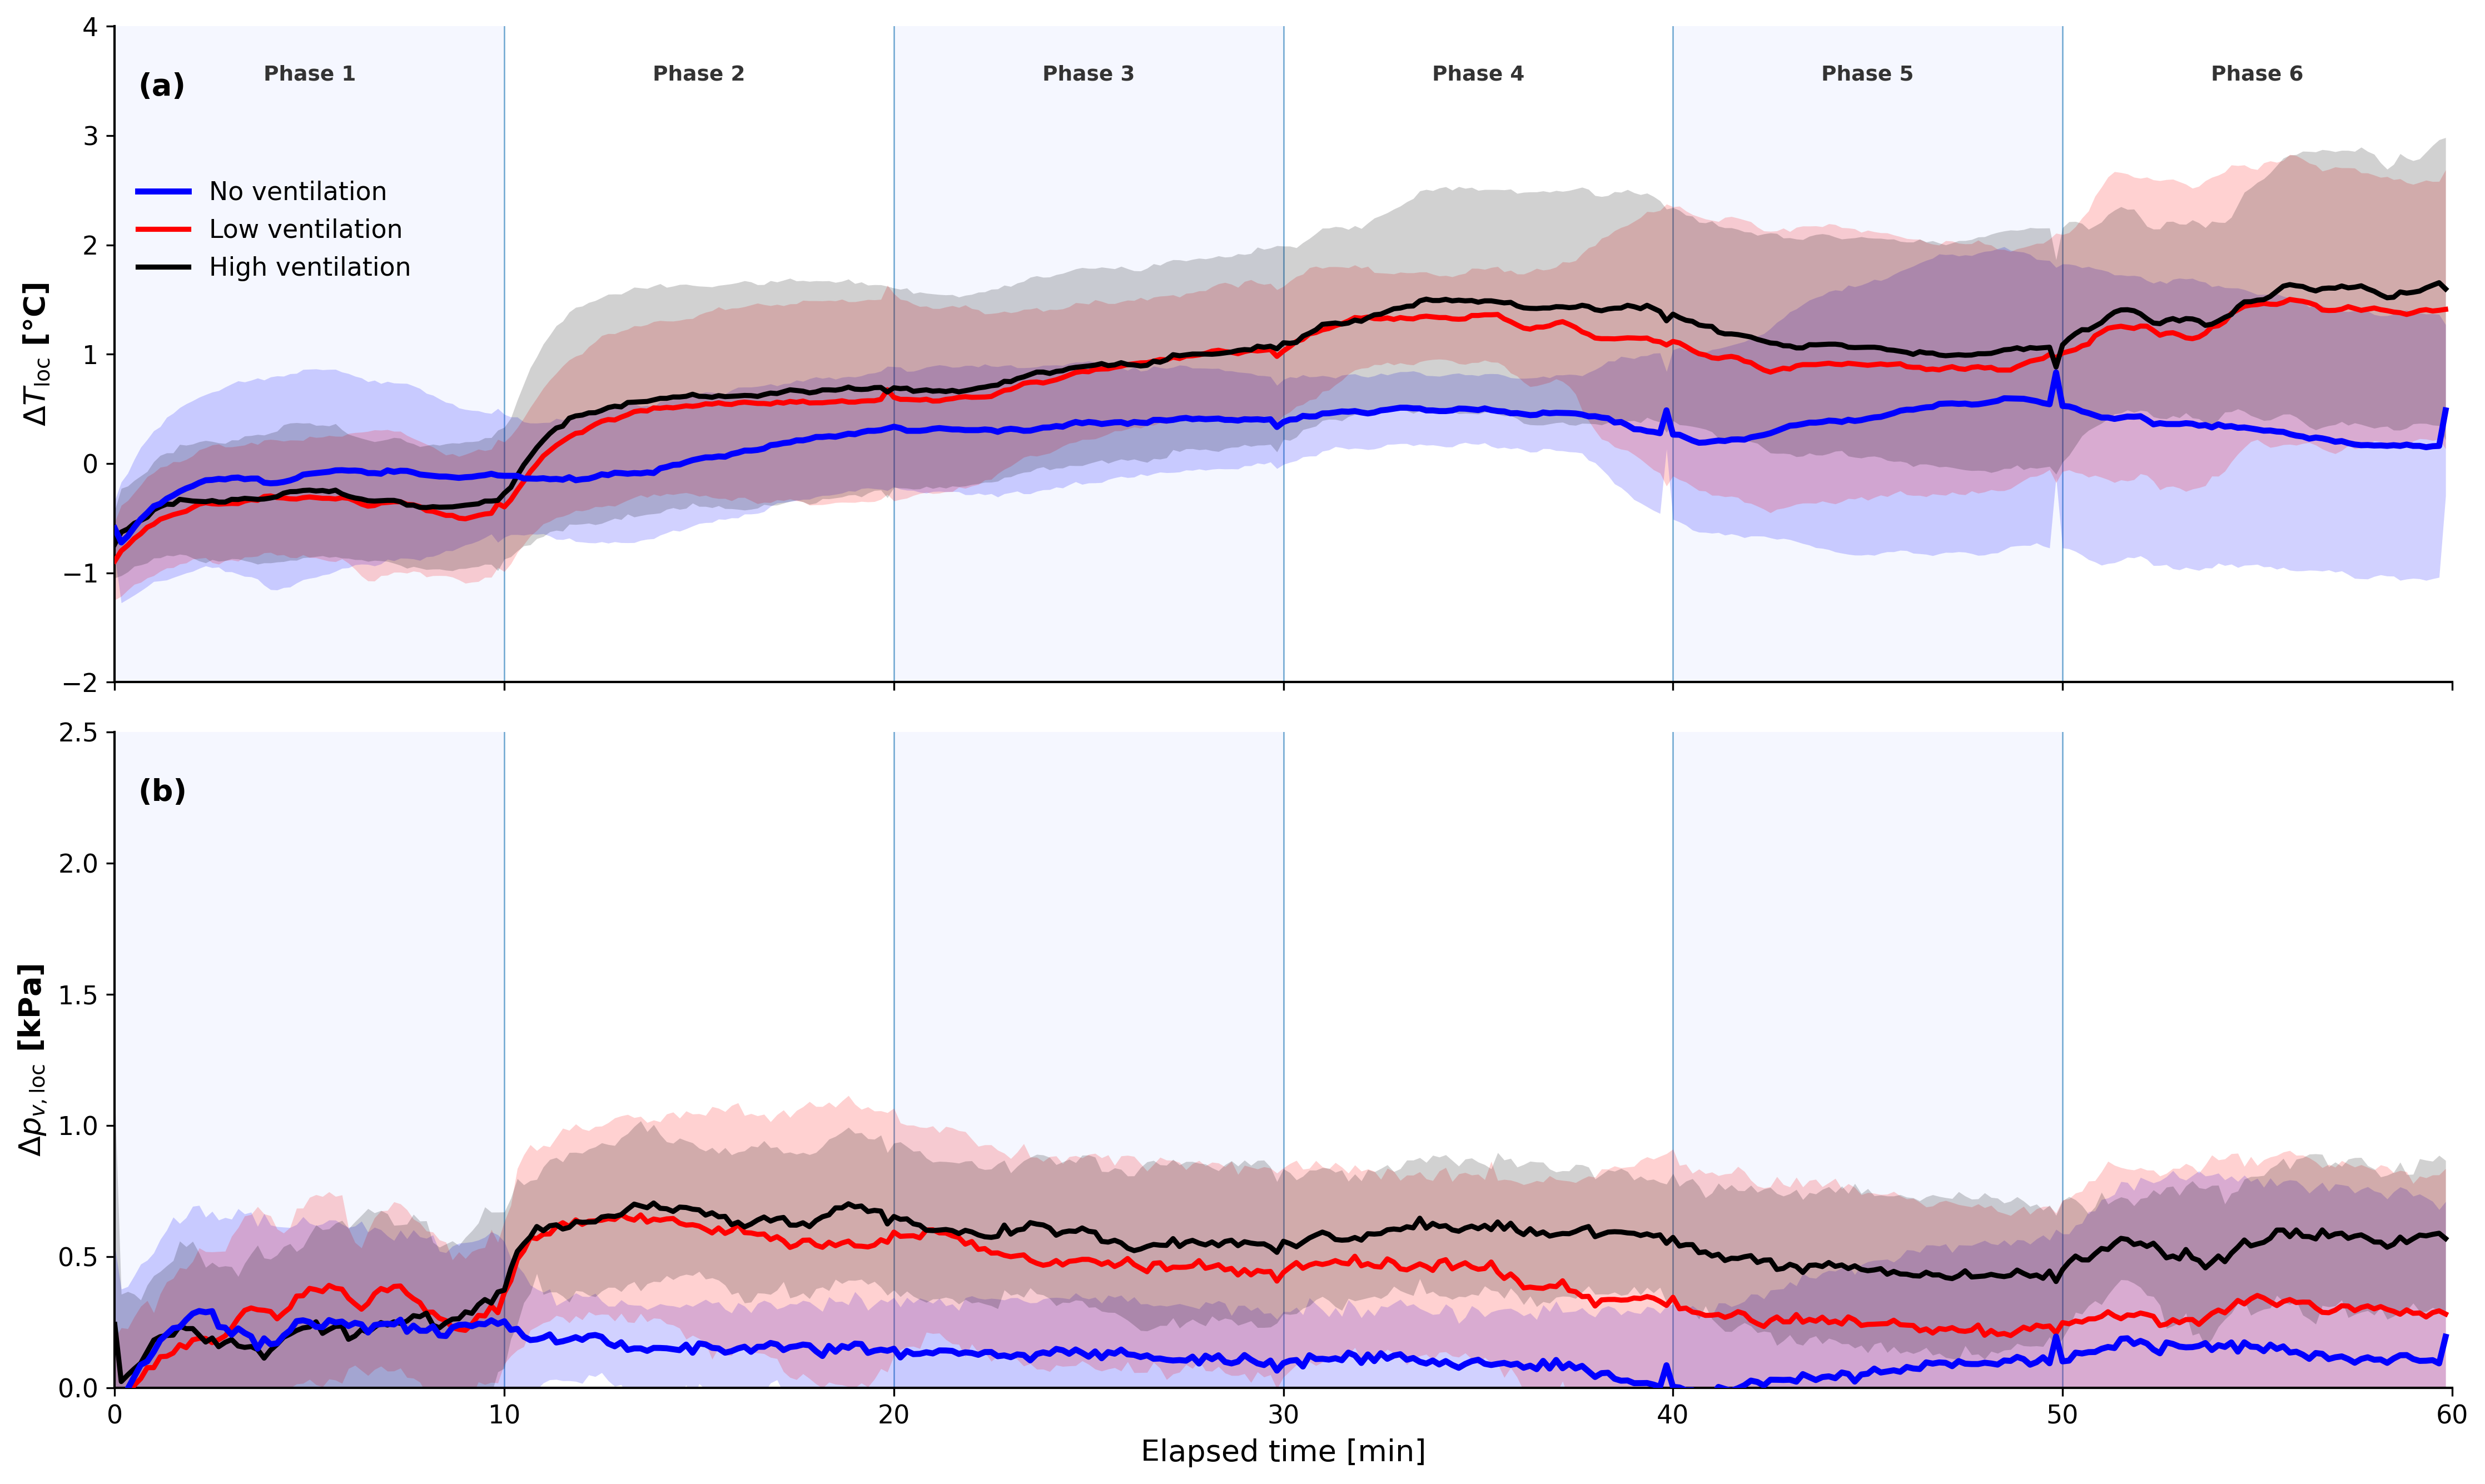

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

INPUT_PATH = (
    ROOT
    / "data"
    / "processed"
    / "analysis"
    / "analysis_wide_thermodynamics.csv"
)

OUTPUT_DIR = ROOT / "reports" / "9_humidity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Thermodynamic dataset not found: {INPUT_PATH}\n"
        "Run the previous cell before generating the figure."
    )

print(f"Loading thermodynamic dataset from: {INPUT_PATH}")


# ============================================================
# LOAD AND CLEAN
# ============================================================

df = pd.read_csv(INPUT_PATH)

df["subject_id"] = (
    df["subject_id"]
    .astype(str)
    .str.strip()
)

df["condition"] = (
    df["condition"]
    .astype(str)
    .str.strip()
    .str.lower()
)

required_columns = [
    "subject_id",
    "condition",
    "elapsed_minutes_bin",
    "delta_T_loc",
    "delta_pv_loc",
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        "Missing required columns in the thermodynamic dataset: "
        f"{missing_columns}"
    )

for column in [
    "elapsed_minutes_bin",
    "delta_T_loc",
    "delta_pv_loc",
]:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )


# ============================================================
# REMOVE INVALID OR TERMINAL TIME POINTS
# ============================================================

# Keep the experimental interval in the form [0, 60).
# The point exactly at 60 min is excluded because it lies outside
# the nominal acquisition window and may produce artificial spikes.
df = df.loc[
    (df["elapsed_minutes_bin"] >= 0)
    & (df["elapsed_minutes_bin"] < 60)
].copy()


# ============================================================
# DIAGNOSTICS
# ============================================================

print("\nConditions found:")

print(
    df["condition"]
    .value_counts(dropna=False)
)

print("\nSubjects contributing to each condition:")

print(
    df
    .groupby("condition")["subject_id"]
    .nunique()
)

print("\nSubjects contributing to delta_T_loc:")

print(
    df
    .dropna(subset=["delta_T_loc"])
    .groupby("condition")["subject_id"]
    .nunique()
)

print("\nSubjects contributing to delta_pv_loc:")

print(
    df
    .dropna(subset=["delta_pv_loc"])
    .groupby("condition")["subject_id"]
    .nunique()
)


# ============================================================
# SUBJECT-LEVEL TEMPORAL DATA
# ============================================================

# Average repeated observations within each subject, condition,
# and temporal bin before calculating across-subject statistics.
subject_time = (
    df
    .groupby(
        [
            "subject_id",
            "condition",
            "elapsed_minutes_bin",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        delta_T_loc=(
            "delta_T_loc",
            "mean",
        ),
        delta_pv_loc=(
            "delta_pv_loc",
            "mean",
        ),
    )
)


# ============================================================
# ACROSS-SUBJECT MEAN AND STANDARD DEVIATION
# ============================================================

def calculate_time_statistics(data, variable):
    """
    Calculate the across-subject mean and standard deviation
    at each temporal bin.

    The ribbon limits are defined as mean +/- 1 standard deviation.
    """

    stats = (
        data
        .dropna(subset=[variable])
        .groupby(
            "elapsed_minutes_bin",
            observed=True,
        )[variable]
        .agg(
            mean="mean",
            std="std",
            n="count",
        )
        .reset_index()
        .sort_values("elapsed_minutes_bin")
    )

    if stats.empty:
        return stats

    # Standard deviation is undefined for fewer than two subjects.
    stats.loc[
        stats["n"] < 2,
        "std",
    ] = np.nan

    stats["lower_sd"] = (
        stats["mean"]
        - stats["std"]
    )

    stats["upper_sd"] = (
        stats["mean"]
        + stats["std"]
    )

    return stats


# ============================================================
# PLOT SETTINGS
# ============================================================

condition_order = [
    "no_wind",
    "wind_low",
    "wind_high",
]

condition_style = {
    "no_wind": {
        "color": "blue",
        "label": "No ventilation",
    },
    "wind_low": {
        "color": "red",
        "label": "Low ventilation",
    },
    "wind_high": {
        "color": "black",
        "label": "High ventilation",
    },
}

phases_info = [
    {
        "start": 0,
        "end": 10,
        "label": "Phase 1",
        "fill": True,
    },
    {
        "start": 10,
        "end": 20,
        "label": "Phase 2",
        "fill": False,
    },
    {
        "start": 20,
        "end": 30,
        "label": "Phase 3",
        "fill": True,
    },
    {
        "start": 30,
        "end": 40,
        "label": "Phase 4",
        "fill": False,
    },
    {
        "start": 40,
        "end": 50,
        "label": "Phase 5",
        "fill": True,
    },
    {
        "start": 50,
        "end": 60,
        "label": "Phase 6",
        "fill": False,
    },
]

plot_variables = [
    {
        "column": "delta_T_loc",
        "ylabel": r"$\Delta T_{\mathrm{loc}}$ [°C]",
        "panel_label": "(a)",
    },
    {
        "column": "delta_pv_loc",
        "ylabel": r"$\Delta p_{v,\mathrm{loc}}$ [kPa]",
        "panel_label": "(b)",
    },
]


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(15, 9),
    dpi=300,
    sharex=True,
)


# ============================================================
# PHASE BACKGROUND
# ============================================================

for ax in axes:

    for phase in phases_info:

        if phase["fill"]:
            ax.axvspan(
                phase["start"],
                phase["end"],
                facecolor="#eff3ff",
                alpha=0.6,
                zorder=0,
            )

        if phase["end"] < 60:
            ax.axvline(
                phase["end"],
                color="#3182bd",
                linewidth=0.6,
                alpha=0.7,
                zorder=1,
            )


# ============================================================
# MEAN TRAJECTORIES AND +/- 1 STANDARD DEVIATION
# ============================================================

for ax, plot_info in zip(
    axes,
    plot_variables,
):

    variable = plot_info["column"]

    for condition in condition_order:

        condition_data = subject_time.loc[
            subject_time["condition"] == condition
        ].copy()

        stats = calculate_time_statistics(
            condition_data,
            variable,
        )

        if stats.empty:
            print(
                f"WARNING: no valid data for condition "
                f"'{condition}' and variable '{variable}'."
            )
            continue

        x = stats[
            "elapsed_minutes_bin"
        ].to_numpy(dtype=float)

        mean = stats[
            "mean"
        ].to_numpy(dtype=float)

        lower = stats[
            "lower_sd"
        ].to_numpy(dtype=float)

        upper = stats[
            "upper_sd"
        ].to_numpy(dtype=float)

        valid_sd = (
            np.isfinite(lower)
            & np.isfinite(upper)
        )

        if valid_sd.any():
            ax.fill_between(
                x,
                lower,
                upper,
                where=valid_sd,
                color=condition_style[condition]["color"],
                alpha=0.18,
                linewidth=0,
                interpolate=True,
                zorder=2,
            )

        line_zorder = (
            5
            if condition == "no_wind"
            else 4
        )

        line_width = (
            2.6
            if condition == "no_wind"
            else 2.2
        )

        ax.plot(
            x,
            mean,
            color=condition_style[condition]["color"],
            label=condition_style[condition]["label"],
            linewidth=line_width,
            zorder=line_zorder,
        )

    ax.set_ylabel(
        plot_info["ylabel"],
        fontsize=13,
        fontweight="bold",
    )

    ax.text(
        0.01,
        0.93,
        plot_info["panel_label"],
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

    ax.tick_params(
        axis="both",
        labelsize=11,
    )


# ============================================================
# MANUAL AXIS LIMITS
# ============================================================

# Panel (a): local temperature difference
axes[0].set_ylim(
    -2.0,
    4.0,
)

axes[0].set_yticks(
    np.arange(
        -2.0,
        4.1,
        1.0,
    )
)

# Panel (b): local vapour-pressure difference
axes[1].set_ylim(
    0.0,
    2.5,
)

axes[1].set_yticks(
    np.arange(
        0.0,
        2.51,
        0.5,
    )
)


# ============================================================
# PHASE LABELS
# ============================================================

top_ax = axes[0]

# Position labels inside the manually defined axis range.
phase_label_y = 3.65

for phase in phases_info:

    x_center = (
        phase["start"]
        + phase["end"]
    ) / 2

    top_ax.text(
        x_center,
        phase_label_y,
        phase["label"],
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )


# ============================================================
# FINAL FORMATTING
# ============================================================

axes[-1].set_xlabel(
    "Elapsed time [min]",
    fontsize=13,
)

axes[-1].set_xlim(
    0,
    60,
)

axes[-1].set_xticks(
    np.arange(
        0,
        61,
        10,
    )
)


# ============================================================
# LEGEND
# ============================================================

handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)

legend_order = [
    labels.index(
        condition_style[condition]["label"]
    )
    for condition in condition_order
    if condition_style[condition]["label"] in labels
]

axes[0].legend(
    [
        handles[index]
        for index in legend_order
    ],
    [
        labels[index]
        for index in legend_order
    ],
    loc="upper left",
    bbox_to_anchor=(0, 0.8),
    frameon=False,
    fontsize=11,
    ncol=1,
)


# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

output_path = (
    OUTPUT_DIR
    / "paper_thermohygrometric_driving_forces_sd.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"\nFigure saved to: {output_path}")

plt.show()

## 3. Nested leave-one-subject-out comparison of M0, M1 and M2


In [4]:
# ============================================================
# NESTED LEAVE-ONE-SUBJECT-OUT VALIDATION OF M0, M1 AND M2
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf


CV_OUTPUT_DIR = (
    ROOT / "reports" / "9_humidity" / "nested_loso_model_comparison"
)
CV_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TIME_STEP_SECONDS = 10
HISTORY_WINDOWS_SECONDS = np.arange(10, 301, TIME_STEP_SECONDS)
MAX_HISTORY_WINDOW_SECONDS = int(HISTORY_WINDOWS_SECONDS.max())

CONDITION_ORDER = ["no_wind", "wind_low", "wind_high"]
PHASE_ORDER = [
    "phase_1", "phase_2", "phase_3",
    "phase_4", "phase_5", "phase_6",
]
PHASE_START_SECONDS = {
    "phase_1": 0,
    "phase_2": 600,
    "phase_3": 1200,
    "phase_4": 1800,
    "phase_5": 2400,
    "phase_6": 3000,
}


def assign_phase(elapsed_minutes):
    phase_number = int(elapsed_minutes // 10) + 1
    if 1 <= phase_number <= 6:
        return f"phase_{phase_number}"
    return np.nan


# Reload the unfiltered thermodynamic table. In particular, do not use
# outcome-dependent trimming calculated from the held-out participant.
cv_df = pd.read_csv(INPUT_PATH)

required_columns = [
    "subject_id", "condition", "elapsed_seconds_bin",
    "elapsed_minutes_bin", "delta_T_loc", "delta_pv_loc",
    "dT_dorsal_dt",
]
missing_columns = [c for c in required_columns if c not in cv_df.columns]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

cv_df["subject_id"] = cv_df["subject_id"].astype(str).str.strip()
cv_df["condition"] = cv_df["condition"].astype(str).str.strip().str.lower()

for column in [
    "elapsed_seconds_bin", "elapsed_minutes_bin", "delta_T_loc",
    "delta_pv_loc", "dT_dorsal_dt",
]:
    cv_df[column] = pd.to_numeric(cv_df[column], errors="coerce")

cv_df = cv_df.loc[
    (cv_df["elapsed_minutes_bin"] >= 0)
    & (cv_df["elapsed_minutes_bin"] < 60)
].copy()

cv_df["phase"] = cv_df["elapsed_minutes_bin"].apply(assign_phase)
cv_df["phase_start_seconds"] = cv_df["phase"].map(PHASE_START_SECONDS)
cv_df["seconds_from_phase_start"] = (
    cv_df["elapsed_seconds_bin"] - cv_df["phase_start_seconds"]
)

for column in ["delta_T_loc", "delta_pv_loc", "dT_dorsal_dt"]:
    cv_df.loc[~np.isfinite(cv_df[column]), column] = np.nan

cv_df = cv_df.sort_values(
    ["subject_id", "condition", "phase", "elapsed_seconds_bin"]
).reset_index(drop=True)


# ============================================================
# STRICTLY PAST CUMULATIVE PREDICTORS
# ============================================================

group_columns = ["subject_id", "condition", "phase"]
history_columns = []

for window_seconds in HISTORY_WINDOWS_SECONDS:
    window_steps = window_seconds // TIME_STEP_SECONDS
    history_column = f"delta_pv_history_mean_{window_seconds}s"
    history_columns.append(history_column)

    cv_df[history_column] = (
        cv_df.groupby(group_columns, observed=True, sort=False)["delta_pv_loc"]
        .transform(
            lambda series: (
                series.shift(1)
                .rolling(window=window_steps, min_periods=window_steps)
                .mean()
            )
        )
    )


# All candidate windows and all models are evaluated on the same rows.
# Restricting outcomes to 300--600 s gives every window enough past data.
common_columns = [
    "subject_id", "condition", "phase", "elapsed_seconds_bin",
    "delta_T_loc", "delta_pv_loc", "dT_dorsal_dt",
] + history_columns

cv_model_data = (
    cv_df.loc[
        cv_df["seconds_from_phase_start"] >= MAX_HISTORY_WINDOW_SECONDS,
        common_columns,
    ]
    .dropna(subset=common_columns)
    .copy()
)

subjects = sorted(cv_model_data["subject_id"].unique())
if len(subjects) < 4:
    raise RuntimeError(
        "Nested leave-one-subject-out validation requires at least 4 subjects."
    )

print(f"Subjects available for nested LOSO: {len(subjects)}")
print(f"Common complete observations: {len(cv_model_data)}")


MODEL_PREDICTORS = {
    "M0": ["delta_T_loc"],
    "M1": ["delta_T_loc", "delta_pv_loc"],
}


def fit_ols(train_data, predictors):
    X = sm.add_constant(train_data[predictors], has_constant="add")
    return sm.OLS(train_data["dT_dorsal_dt"], X).fit()


def predict_ols(result, test_data, predictors):
    X = sm.add_constant(test_data[predictors], has_constant="add")
    X = X.reindex(columns=result.model.exog_names, fill_value=1.0)
    return np.asarray(result.predict(X), dtype=float)


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def select_history_window_nested(training_data):
    """Choose W using only subjects in the outer training set."""
    training_subjects = sorted(training_data["subject_id"].unique())
    window_rows = []

    for window_seconds in HISTORY_WINDOWS_SECONDS:
        history_column = f"delta_pv_history_mean_{window_seconds}s"
        predictors = ["delta_T_loc", "delta_pv_loc", history_column]
        inner_squared_errors = []

        for validation_subject in training_subjects:
            inner_train = training_data.loc[
                training_data["subject_id"] != validation_subject
            ]
            inner_valid = training_data.loc[
                training_data["subject_id"] == validation_subject
            ]

            if inner_train.empty or inner_valid.empty:
                continue

            result = fit_ols(inner_train, predictors)
            prediction = predict_ols(result, inner_valid, predictors)
            inner_squared_errors.extend(
                (inner_valid["dT_dorsal_dt"].to_numpy() - prediction) ** 2
            )

        inner_rmse = (
            float(np.sqrt(np.mean(inner_squared_errors)))
            if inner_squared_errors else np.nan
        )
        window_rows.append(
            {
                "history_window_seconds": window_seconds,
                "inner_loso_rmse": inner_rmse,
            }
        )

    window_scores = pd.DataFrame(window_rows).dropna(subset=["inner_loso_rmse"])
    if window_scores.empty:
        raise RuntimeError("No cumulative window could be evaluated in inner LOSO.")

    # Deterministic tie break: prefer the shorter window.
    best = window_scores.sort_values(
        ["inner_loso_rmse", "history_window_seconds"]
    ).iloc[0]
    return int(best["history_window_seconds"]), window_scores


def run_nested_loso(data, analysis_level, analysis_group):
    prediction_rows = []
    selection_rows = []
    available_subjects = sorted(data["subject_id"].unique())

    for outer_subject in available_subjects:
        outer_train = data.loc[data["subject_id"] != outer_subject].copy()
        outer_test = data.loc[data["subject_id"] == outer_subject].copy()

        if outer_train.empty or outer_test.empty:
            continue

        best_window, inner_scores = select_history_window_nested(outer_train)
        best_history_column = f"delta_pv_history_mean_{best_window}s"

        selection_rows.append(
            {
                "analysis_level": analysis_level,
                "analysis_group": analysis_group,
                "outer_subject": outer_subject,
                "selected_window_seconds": best_window,
                "inner_loso_rmse": float(
                    inner_scores.loc[
                        inner_scores["history_window_seconds"] == best_window,
                        "inner_loso_rmse",
                    ].iloc[0]
                ),
            }
        )

        fold_models = {
            "M0": MODEL_PREDICTORS["M0"],
            "M1": MODEL_PREDICTORS["M1"],
            "M2": ["delta_T_loc", "delta_pv_loc", best_history_column],
        }

        for model_name, predictors in fold_models.items():
            result = fit_ols(outer_train, predictors)
            predicted = predict_ols(result, outer_test, predictors)

            fold_predictions = outer_test[
                [
                    "subject_id", "condition", "phase",
                    "elapsed_seconds_bin", "dT_dorsal_dt",
                ]
            ].copy()
            fold_predictions["analysis_level"] = analysis_level
            fold_predictions["analysis_group"] = analysis_group
            fold_predictions["model"] = model_name
            fold_predictions["predicted_dT_dorsal_dt"] = predicted
            fold_predictions["selected_window_seconds"] = (
                best_window if model_name == "M2" else np.nan
            )
            prediction_rows.append(fold_predictions)

    return pd.concat(prediction_rows, ignore_index=True), pd.DataFrame(selection_rows)


# Evaluate the overall dataset and every phase. The outer test participant
# never contributes to fitting or to selection of the M2 history window.
all_predictions = []
all_selections = []

analysis_groups = [("overall", "all", cv_model_data)]
analysis_groups.extend(
    (
        "phase",
        phase,
        cv_model_data.loc[cv_model_data["phase"] == phase].copy(),
    )
    for phase in PHASE_ORDER
)

for analysis_level, analysis_group, analysis_data in analysis_groups:
    print(f"Running nested LOSO: {analysis_level} / {analysis_group}")
    predictions, selections = run_nested_loso(
        analysis_data, analysis_level, analysis_group
    )
    all_predictions.append(predictions)
    all_selections.append(selections)

cv_predictions = pd.concat(all_predictions, ignore_index=True)
cv_selected_windows = pd.concat(all_selections, ignore_index=True)


# ============================================================
# HELD-OUT METRICS
# ============================================================

def summarize_errors(group):
    residual = (
        group["dT_dorsal_dt"].to_numpy()
        - group["predicted_dT_dorsal_dt"].to_numpy()
    )
    return pd.Series(
        {
            "n_observations": len(group),
            "rmse_C_per_s": float(np.sqrt(np.mean(residual ** 2))),
            "mae_C_per_s": float(np.mean(np.abs(residual))),
        }
    )


# Paired experimental-unit errors used for statistical comparison.
cv_unit_metrics = (
    cv_predictions.groupby(
        [
            "analysis_level", "analysis_group", "subject_id",
            "condition", "phase", "model",
        ],
        observed=True,
    )
    .apply(summarize_errors)
    .reset_index()
)
cv_unit_metrics["rmse_C_per_min"] = cv_unit_metrics["rmse_C_per_s"] * 60
cv_unit_metrics["mae_C_per_min"] = cv_unit_metrics["mae_C_per_s"] * 60


def pooled_group_metrics(group):
    y = group["dT_dorsal_dt"].to_numpy()
    prediction = group["predicted_dT_dorsal_dt"].to_numpy()
    residual_ss = np.sum((y - prediction) ** 2)
    total_ss = np.sum((y - np.mean(y)) ** 2)
    return pd.Series(
        {
            "n_observations": len(group),
            "heldout_rmse_C_per_min": rmse(y, prediction) * 60,
            "heldout_mae_C_per_min": np.mean(np.abs(y - prediction)) * 60,
            "heldout_r2": 1 - residual_ss / total_ss if total_ss > 0 else np.nan,
        }
    )


cv_group_metrics = (
    cv_predictions.groupby(
        ["analysis_level", "analysis_group", "model"], observed=True
    )
    .apply(pooled_group_metrics)
    .reset_index()
)


# Paired differences: positive values mean that the enriched model is better.
metric_wide = cv_unit_metrics.pivot(
    index=[
        "analysis_level", "analysis_group", "subject_id", "condition", "phase"
    ],
    columns="model",
    values="rmse_C_per_min",
).reset_index()
metric_wide["delta_rmse_M0_minus_M1"] = metric_wide["M0"] - metric_wide["M1"]
metric_wide["delta_rmse_M1_minus_M2"] = metric_wide["M1"] - metric_wide["M2"]


# ============================================================
# SUBJECT-LEVEL PAIRED INFERENCE
# ============================================================

from itertools import product
from statsmodels.stats.multitest import multipletests


def exact_sign_flip_test(values):
    """Exact two-sided paired randomization test on the mean difference."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan
    observed = abs(values.mean())
    permuted = np.array(
        [
            abs(np.mean(values * np.asarray(signs)))
            for signs in product([-1.0, 1.0], repeat=len(values))
        ]
    )
    return float(np.mean(permuted >= observed - 1e-15))


def bootstrap_mean_ci(values, n_bootstrap=10000, seed=20260831):
    """Percentile CI obtained by resampling complete participants."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(values), size=(n_bootstrap, len(values)))
    means = values[indices].mean(axis=1)
    return tuple(np.quantile(means, [0.025, 0.975]))


COMPARISONS = {
    "M0_vs_M1": ("M0", "M1"),
    "M1_vs_M2": ("M1", "M2"),
}


def subject_level_values(data, baseline_model, enriched_model, grouping_columns):
    """Average paired RMSE differences within each participant."""
    result = data.copy()
    result["delta_rmse_C_per_min"] = (
        result[baseline_model] - result[enriched_model]
    )
    result["relative_improvement"] = (
        result["delta_rmse_C_per_min"] / result[baseline_model]
    )
    return (
        result.groupby(grouping_columns + ["subject_id"], observed=True)
        .agg(
            delta_rmse_C_per_min=("delta_rmse_C_per_min", "mean"),
            relative_improvement=("relative_improvement", "mean"),
        )
        .reset_index()
    )


def summarize_subject_differences(subject_data, seed_offset=0):
    values = subject_data["delta_rmse_C_per_min"].to_numpy()
    relative = subject_data["relative_improvement"].to_numpy()
    ci_low, ci_high = bootstrap_mean_ci(
        values, seed=20260831 + seed_offset
    )
    return {
        "n_subjects": len(values),
        "mean_delta_rmse_C_per_min": float(np.mean(values)),
        "median_delta_rmse_C_per_min": float(np.median(values)),
        "ci_low": ci_low,
        "ci_high": ci_high,
        "mean_relative_improvement_percent": float(np.mean(relative) * 100),
        "subjects_improved": int(np.sum(values > 0)),
        "subjects_worsened": int(np.sum(values < 0)),
        "p_sign_flip_raw": exact_sign_flip_test(values),
    }


paired_subject_rows = []
paired_summary_rows = []
condition_summary_rows = []

for comparison_index, (
    comparison,
    (baseline_model, enriched_model),
) in enumerate(COMPARISONS.items()):

    # Overall comparison: average all condition-by-phase differences
    # within each participant before inference.
    overall_data = metric_wide.loc[
        metric_wide["analysis_level"] == "overall"
    ].copy()
    overall_subject = subject_level_values(
        overall_data,
        baseline_model,
        enriched_model,
        grouping_columns=[],
    )
    overall_subject["scope"] = "overall"
    overall_subject["analysis_group"] = "all"
    overall_subject["condition"] = "all"
    overall_subject["comparison"] = comparison
    paired_subject_rows.append(overall_subject)

    overall_summary = summarize_subject_differences(
        overall_subject, seed_offset=100 * comparison_index
    )
    overall_summary.update(
        {
            "scope": "overall",
            "analysis_group": "all",
            "condition": "all",
            "comparison": comparison,
            "baseline_model": baseline_model,
            "enriched_model": enriched_model,
        }
    )
    paired_summary_rows.append(overall_summary)

    # Phase-specific primary comparisons: average the three conditions
    # within participant, then test across participants.
    for phase_index, phase in enumerate(PHASE_ORDER):
        phase_data = metric_wide.loc[
            (metric_wide["analysis_level"] == "phase")
            & (metric_wide["analysis_group"] == phase)
        ].copy()
        phase_subject = subject_level_values(
            phase_data,
            baseline_model,
            enriched_model,
            grouping_columns=["analysis_group"],
        )
        phase_subject["scope"] = "phase"
        phase_subject["condition"] = "all"
        phase_subject["comparison"] = comparison
        paired_subject_rows.append(phase_subject)

        phase_summary = summarize_subject_differences(
            phase_subject,
            seed_offset=1000 + 100 * comparison_index + phase_index,
        )
        phase_summary.update(
            {
                "scope": "phase",
                "analysis_group": phase,
                "condition": "all",
                "comparison": comparison,
                "baseline_model": baseline_model,
                "enriched_model": enriched_model,
            }
        )
        paired_summary_rows.append(phase_summary)

        # Exploratory phase-by-condition comparisons.
        for condition_index, condition in enumerate(CONDITION_ORDER):
            condition_data = phase_data.loc[
                phase_data["condition"] == condition
            ].copy()
            condition_subject = subject_level_values(
                condition_data,
                baseline_model,
                enriched_model,
                grouping_columns=["analysis_group", "condition"],
            )
            condition_subject["scope"] = "phase_condition"
            condition_subject["comparison"] = comparison
            paired_subject_rows.append(condition_subject)

            condition_summary = summarize_subject_differences(
                condition_subject,
                seed_offset=(
                    2000 + 100 * comparison_index
                    + 10 * phase_index + condition_index
                ),
            )
            condition_summary.update(
                {
                    "scope": "phase_condition",
                    "analysis_group": phase,
                    "condition": condition,
                    "comparison": comparison,
                    "baseline_model": baseline_model,
                    "enriched_model": enriched_model,
                }
            )
            condition_summary_rows.append(condition_summary)


paired_subject_values = pd.concat(paired_subject_rows, ignore_index=True)
paired_primary_results = pd.DataFrame(paired_summary_rows)
paired_condition_results = pd.DataFrame(condition_summary_rows)


# Holm adjustment is applied separately to the six planned phase tests
# for each model comparison. Overall tests are reported separately.
paired_primary_results["p_holm"] = paired_primary_results["p_sign_flip_raw"]

for comparison, group in paired_primary_results.loc[
    paired_primary_results["scope"] == "phase"
].groupby("comparison", observed=True):
    adjusted = multipletests(
        group["p_sign_flip_raw"].to_numpy(),
        alpha=0.05,
        method="holm",
    )[1]
    paired_primary_results.loc[group.index, "p_holm"] = adjusted


# Exploratory condition-specific family: 18 phase-by-condition tests
# adjusted together for each model comparison.
paired_condition_results["p_holm"] = np.nan
for comparison, group in paired_condition_results.groupby(
    "comparison", observed=True
):
    adjusted = multipletests(
        group["p_sign_flip_raw"].to_numpy(),
        alpha=0.05,
        method="holm",
    )[1]
    paired_condition_results.loc[group.index, "p_holm"] = adjusted


# Parameter counts make model complexity explicit.
model_complexity = pd.DataFrame(
    {
        "model": ["M0", "M1", "M2"],
        "fitted_coefficients": [2, 3, 4],
        "predictors": [
            "delta_T_loc",
            "delta_T_loc + delta_pv_loc",
            "delta_T_loc + delta_pv_loc + past mean delta_pv_loc",
        ],
    }
)


# Save every value needed to audit and reproduce the comparison.
cv_predictions.to_csv(CV_OUTPUT_DIR / "nested_loso_predictions.csv", index=False)
cv_selected_windows.to_csv(
    CV_OUTPUT_DIR / "nested_loso_selected_windows.csv", index=False
)
cv_unit_metrics.to_csv(CV_OUTPUT_DIR / "nested_loso_unit_metrics.csv", index=False)
cv_group_metrics.to_csv(CV_OUTPUT_DIR / "nested_loso_group_metrics.csv", index=False)
metric_wide.to_csv(CV_OUTPUT_DIR / "nested_loso_paired_differences.csv", index=False)
paired_subject_values.to_csv(
    CV_OUTPUT_DIR / "nested_loso_subject_paired_values.csv", index=False
)
paired_primary_results.to_csv(
    CV_OUTPUT_DIR / "nested_loso_paired_inference.csv", index=False
)
paired_condition_results.to_csv(
    CV_OUTPUT_DIR / "nested_loso_condition_inference.csv", index=False
)
model_complexity.to_csv(CV_OUTPUT_DIR / "model_complexity.csv", index=False)

print("\nHeld-out group metrics:")
print(cv_group_metrics.to_string(index=False))
print("\nSelected M2 windows by outer fold:")
print(cv_selected_windows.to_string(index=False))
print("\nPrimary paired inference:")
print(paired_primary_results.to_string(index=False))
print("\nExploratory condition-specific inference:")
print(paired_condition_results.to_string(index=False))


Subjects available for nested LOSO: 10
Common complete observations: 5363
Running nested LOSO: overall / all
Running nested LOSO: phase / phase_1
Running nested LOSO: phase / phase_2
Running nested LOSO: phase / phase_3
Running nested LOSO: phase / phase_4
Running nested LOSO: phase / phase_5
Running nested LOSO: phase / phase_6


/tmp/ipykernel_845387/2435108658.py:318: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_errors)
/tmp/ipykernel_845387/2435108658.py:344: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(pooled_group_metrics)



Held-out group metrics:
analysis_level analysis_group model  n_observations  heldout_rmse_C_per_min  heldout_mae_C_per_min  heldout_r2
       overall            all    M0          5363.0                5.493206               3.091846   -0.004751
       overall            all    M1          5363.0                5.514875               3.135445   -0.012693
       overall            all    M2          5363.0                5.448961               3.238926    0.011370
         phase        phase_1    M0           878.0                3.282714               2.385015    0.043742
         phase        phase_1    M1           878.0                3.318370               2.377023    0.022856
         phase        phase_1    M2           878.0                3.294589               2.367369    0.036811
         phase        phase_2    M0           897.0                3.616377               2.661210   -0.078161
         phase        phase_2    M1           897.0                3.746800            

## 4. Incremental held-out performance figure


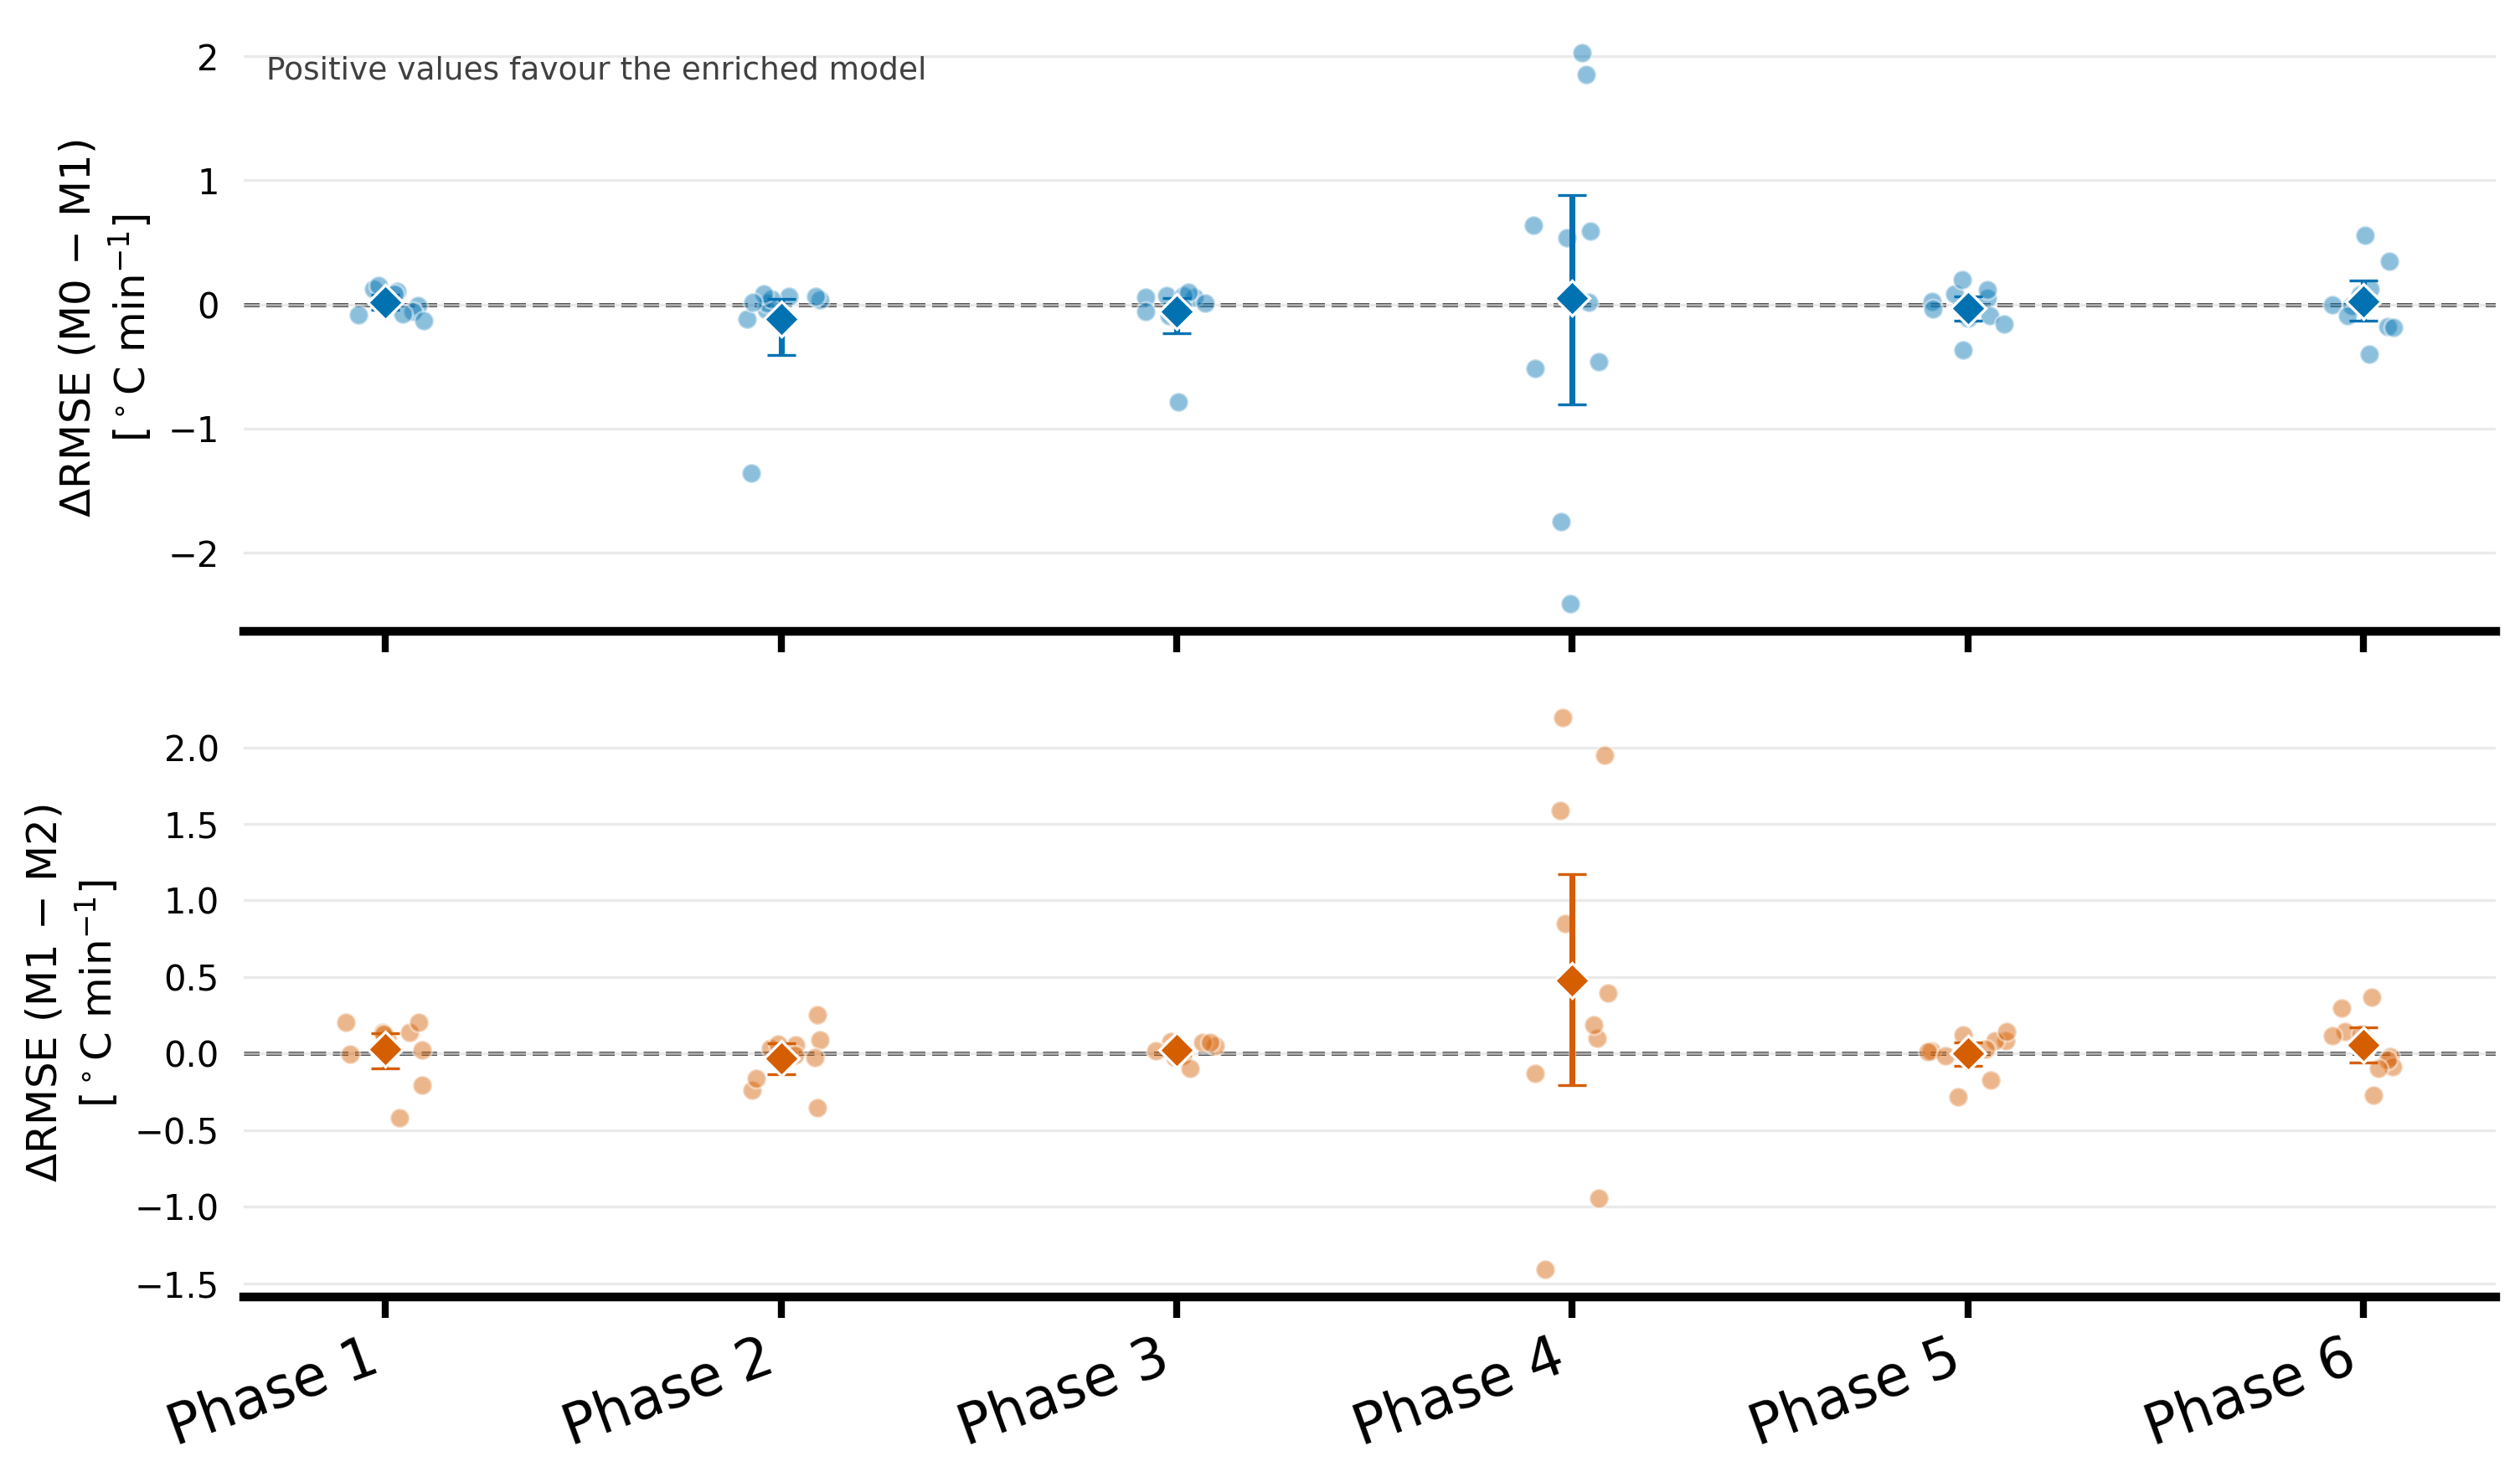

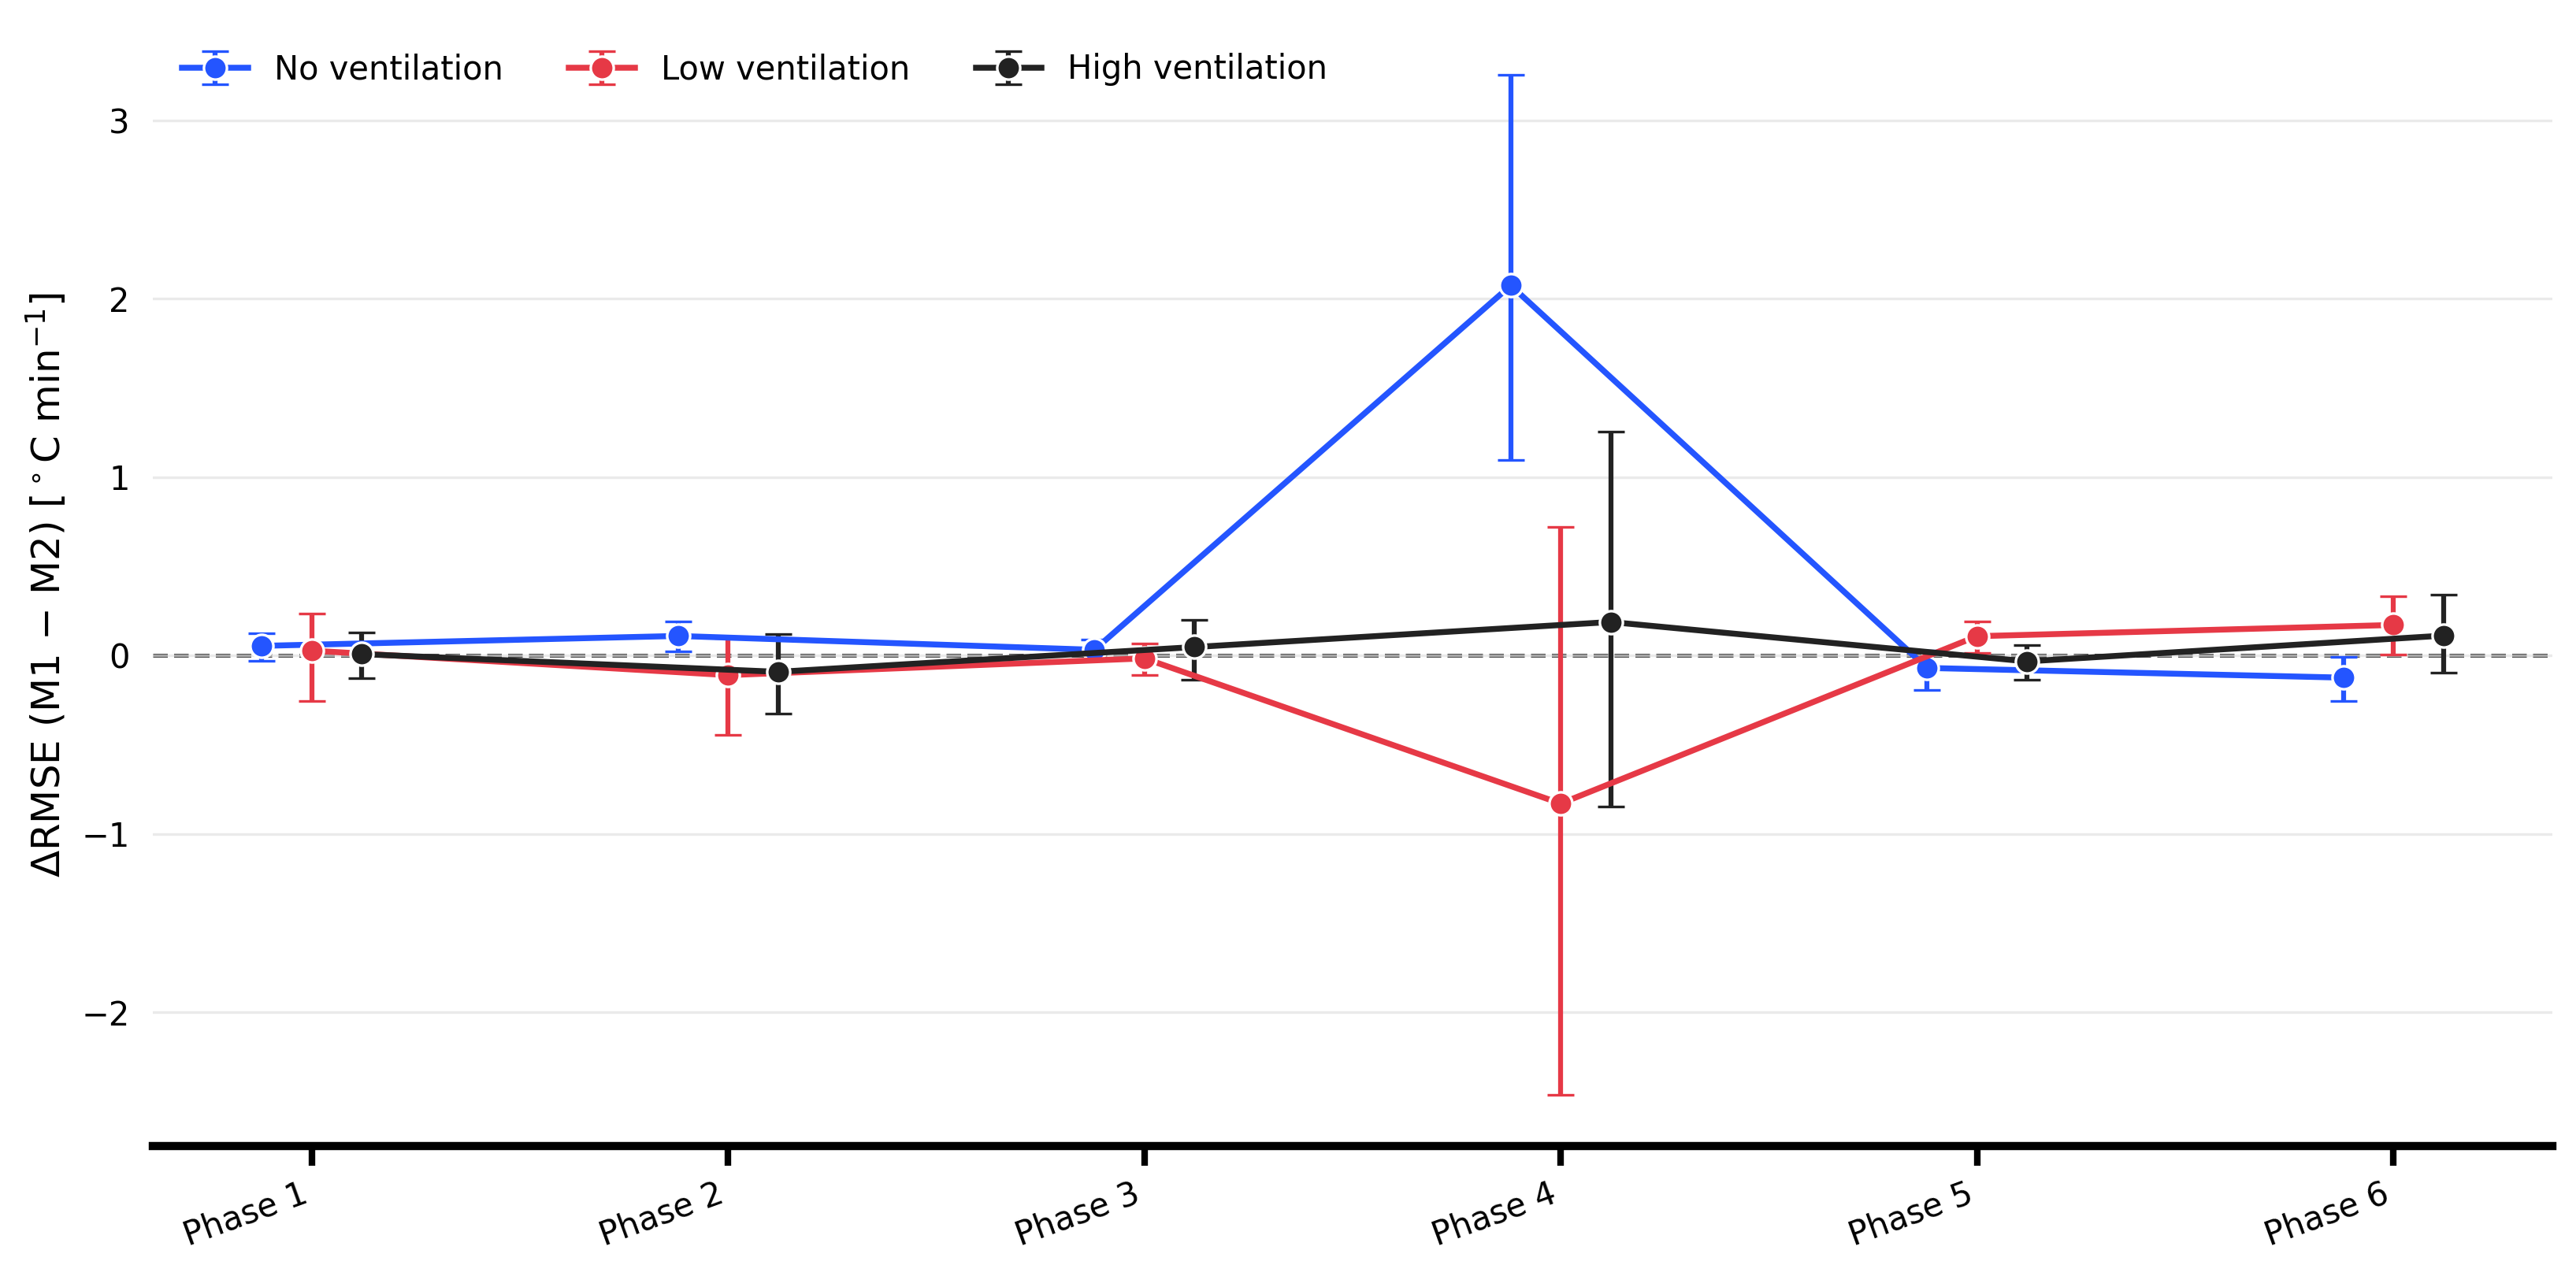

Main figure saved to: /home/eleonorab/repository/convective_cooling/reports/9_humidity/nested_loso_model_comparison/nested_loso_incremental_performance.png
Condition figure saved to: /home/eleonorab/repository/convective_cooling/reports/9_humidity/nested_loso_model_comparison/nested_loso_M2_gain_by_condition.png

Primary paired inference:
 n_subjects  mean_delta_rmse_C_per_min  median_delta_rmse_C_per_min    ci_low   ci_high  mean_relative_improvement_percent  subjects_improved  subjects_worsened  p_sign_flip_raw   scope analysis_group condition comparison baseline_model enriched_model   p_holm
         10                  -0.031788                    -0.014775 -0.078860 -0.002179                          -4.426038                  3                  7         0.062500 overall            all       all   M0_vs_M1             M0             M1 0.062500
         10                   0.016024                     0.016850 -0.042968  0.076408                           3.034475               

In [5]:
# ============================================================
# FIGURE 7: INCREMENTAL HELD-OUT PERFORMANCE
# ============================================================

import matplotlib.pyplot as plt


PHASE_LABELS_SHORT = {
    "phase_1": "Phase 1",
    "phase_2": "Phase 2",
    "phase_3": "Phase 3",
    "phase_4": "Phase 4",
    "phase_5": "Phase 5",
    "phase_6": "Phase 6",
}

COMPARISON_LABELS = {
    "M0_vs_M1": r"M0 $-$ M1",
    "M1_vs_M2": r"M1 $-$ M2",
}

# Colour-blind-friendly colours
COMPARISON_COLORS = {
    "M0_vs_M1": "#0072B2",  # blue
    "M1_vs_M2": "#D55E00",  # vermillion
}


fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    dpi=300,
    sharex=True,
)

x = np.arange(len(PHASE_ORDER))
rng = np.random.default_rng(20260831)


for ax, comparison in zip(
    axes,
    ["M0_vs_M1", "M1_vs_M2"],
):
    comparison_color = COMPARISON_COLORS[comparison]

    subject_data = paired_subject_values.loc[
        (paired_subject_values["scope"] == "phase")
        & (
            paired_subject_values["comparison"]
            == comparison
        )
    ].copy()

    summary_data = (
        paired_primary_results.loc[
            (
                paired_primary_results["scope"]
                == "phase"
            )
            & (
                paired_primary_results["comparison"]
                == comparison
            )
        ]
        .set_index("analysis_group")
        .loc[PHASE_ORDER]
        .reset_index()
    )

    # Individual participant values
    for phase_index, phase in enumerate(PHASE_ORDER):
        values = subject_data.loc[
            subject_data["analysis_group"] == phase,
            "delta_rmse_C_per_min",
        ].to_numpy()

        jitter = rng.uniform(
            -0.10,
            0.10,
            size=len(values),
        )

        ax.scatter(
            np.full(len(values), phase_index) + jitter,
            values,
            s=30,
            facecolor=comparison_color,
            edgecolor="white",
            linewidth=0.7,
            alpha=0.45,
            zorder=2,
        )

    # Mean values and bootstrap confidence intervals
    means = (
        summary_data[
            "mean_delta_rmse_C_per_min"
        ].to_numpy()
    )

    lower = (
        means
        - summary_data["ci_low"].to_numpy()
    )

    upper = (
        summary_data["ci_high"].to_numpy()
        - means
    )

    ax.errorbar(
        x,
        means,
        yerr=np.vstack([lower, upper]),
        fmt="D",
        color=comparison_color,
        markerfacecolor=comparison_color,
        markeredgecolor="white",
        markeredgewidth=0.8,
        markersize=7,
        capsize=4,
        capthick=1.5,
        elinewidth=1.7,
        linewidth=1.7,
        zorder=3,
    )

    # Reference line
    ax.axhline(
        0,
        color="0.25",
        linewidth=1.2,
        linestyle="--",
        zorder=1,
    )

    ax.set_ylabel(
        f"$\\Delta$RMSE "
        f"({COMPARISON_LABELS[comparison]})\n"
        r"[$^\circ$C min$^{-1}$]",
        fontsize=12,
    )

    # Axis formatting
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.spines["bottom"].set_color("black")

    ax.tick_params(
        axis="y",
        left=False,
        labelleft=True,
        labelsize=10,
    )

    ax.tick_params(
        axis="x",
        bottom=True,
        width=2.0,
        length=6,
        labelsize=10,
    )

    ax.grid(
        axis="y",
        color="0.88",
        linewidth=0.8,
        alpha=0.65,
        zorder=0,
    )

    # Significance markers
    for phase_index, row in summary_data.iterrows():
        if row["p_holm"] < 0.05:
            y_position = row["ci_high"]

            ax.text(
                phase_index,
                y_position
                + 0.06
                * max(
                    abs(ax.get_ylim()[0]),
                    abs(ax.get_ylim()[1]),
                ),
                "*",
                color=comparison_color,
                ha="center",
                va="bottom",
                fontsize=16,
                fontweight="bold",
            )


axes[0].text(
    0.01,
    0.95,
    "Positive values favour the enriched model",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color="0.25",
)

axes[-1].set_xticks(x)

axes[-1].set_xticklabels(
    [
        PHASE_LABELS_SHORT[phase]
        for phase in PHASE_ORDER
    ],
    rotation=20,
    ha="right",
    fontsize=16
)

plt.tight_layout()

figure_path = (
    CV_OUTPUT_DIR
    / "nested_loso_incremental_performance.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# EXPLORATORY FIGURE: M2 GAIN BY CONDITION
# ============================================================

condition_colors = {
    "no_wind": "#2455FF",
    "wind_low": "#E63946",
    "wind_high": "#222222",
}

condition_labels = {
    "no_wind": "No ventilation",
    "wind_low": "Low ventilation",
    "wind_high": "High ventilation",
}

condition_plot = paired_condition_results.loc[
    paired_condition_results["comparison"]
    == "M1_vs_M2"
].copy()


fig_condition, ax = plt.subplots(
    figsize=(11, 5.5),
    dpi=300,
)

offsets = {
    "no_wind": -0.12,
    "wind_low": 0.0,
    "wind_high": 0.12,
}


for condition in CONDITION_ORDER:
    subset = (
        condition_plot.loc[
            condition_plot["condition"] == condition
        ]
        .set_index("analysis_group")
        .loc[PHASE_ORDER]
        .reset_index()
    )

    means = (
        subset[
            "mean_delta_rmse_C_per_min"
        ].to_numpy()
    )

    lower = (
        means
        - subset["ci_low"].to_numpy()
    )

    upper = (
        subset["ci_high"].to_numpy()
        - means
    )

    ax.errorbar(
        x + offsets[condition],
        means,
        yerr=np.vstack([lower, upper]),
        fmt="o-",
        color=condition_colors[condition],
        markerfacecolor=condition_colors[condition],
        markeredgecolor="white",
        markeredgewidth=0.8,
        label=condition_labels[condition],
        capsize=4,
        capthick=1.4,
        elinewidth=1.5,
        linewidth=1.8,
        markersize=7,
        zorder=3,
    )


ax.axhline(
    0,
    color="0.25",
    linewidth=1.2,
    linestyle="--",
    zorder=1,
)

ax.set_ylabel(
    r"$\Delta$RMSE (M1 $-$ M2) "
    r"[$^\circ$C min$^{-1}$]",
    fontsize=12,
)

ax.set_xticks(x)

ax.set_xticklabels(
    [
        PHASE_LABELS_SHORT[phase]
        for phase in PHASE_ORDER
    ],
    rotation=20,
    ha="right",
    fontsize=16
)

ax.legend(
    frameon=False,
    ncol=3,
    fontsize=10,
    loc="upper left",
)

# Remove left, top and right axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Emphasise bottom axis
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_linewidth(2.5)
ax.spines["bottom"].set_color("black")

ax.tick_params(
    axis="y",
    left=False,
    labelleft=True,
    labelsize=10,
)

ax.tick_params(
    axis="x",
    bottom=True,
    width=2.0,
    length=6,
    labelsize=10,
)

ax.grid(
    axis="y",
    color="0.88",
    linewidth=0.8,
    alpha=0.65,
    zorder=0,
)

plt.tight_layout()

condition_figure_path = (
    CV_OUTPUT_DIR
    / "nested_loso_M2_gain_by_condition.png"
)

fig_condition.savefig(
    condition_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(f"Main figure saved to: {figure_path}")
print(
    f"Condition figure saved to: "
    f"{condition_figure_path}"
)

print("\nPrimary paired inference:")
print(
    paired_primary_results.to_string(
        index=False
    )
)

print(
    "\nExploratory phase-by-condition inference:"
)

print(
    paired_condition_results.to_string(
        index=False
    )
)